# Homework 3

## Anna Monso Rodriguez
### A20653295


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

## 0. General functions

In [16]:
# Evaluation helper
def evaluate(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)

    print(name)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print("Confusion Matrix:\n", cm)


## 1. Logistic Regression

### Dataset 1

Tabular dataset: Wine dataset

Characteristics: Numerical features

In [17]:
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target
print(data.feature_names)
print(np.unique(y))
print(data.DESCR)


['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
[0 1 2]
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
M

### 1. Implement logistic regression for two-class discrimination

In [18]:

# The most recent trained parameters
_LOGREG_STATE = {
    "w": None,          # weights incl. bias
    "mu": None,         # feature means (for standardization)
    "std": None,        # feature stds  (for standardization)
    "fit_intercept": True,
    "standardize": True,
}

In [19]:
def sigmoid(z):
    # numerically-stable sigmoid
    pos = z >= 0
    neg = ~pos
    out = np.empty_like(z, dtype=float)
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1 + ez)
    return out

In [20]:
def logistic_train(X, y, lr=0.01, epochs=1000):
    """
    Train binary logistic regression with full-batch gradient descent.
    Uses z-score standardization and an intercept by default.
    Stores parameters in module state for use by logistic_predict().
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    # ensure labels are in {0,1}
    y = (y > 0).astype(float)

    # standardize features
    mu = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-8
    Xn = (X - mu) / std

    # add bias column
    ones = np.ones((Xn.shape[0], 1))
    Xb = np.hstack([ones, Xn])

    # initialize weights (incl. bias)
    w = np.zeros(Xb.shape[1], dtype=float)

    # gradient descent
    for _ in range(int(epochs)):
        p = sigmoid(Xb @ w)          # probabilities
        grad = Xb.T @ (p - y) / Xb.shape[0]
        w -= lr * grad

    # save to state
    _LOGREG_STATE.update({
        "w": w,
        "mu": mu,
        "std": std,
        "fit_intercept": True,
        "standardize": True,
    })


In [21]:
def logistic_predict(X):
    """
    Predict hard labels {0,1} using the most recently trained model.
    """
    if _LOGREG_STATE["w"] is None:
        raise RuntimeError("Model not trained yet. Call logistic_train(X, y, ...) first.")

    X = np.asarray(X, dtype=float)

    # apply stored preprocessing
    if _LOGREG_STATE["standardize"]:
        X = (X - _LOGREG_STATE["mu"]) / _LOGREG_STATE["std"]

    # add bias and compute probs
    if _LOGREG_STATE["fit_intercept"]:
        X = np.hstack([np.ones((X.shape[0], 1)), X])

    p = sigmoid(X @ _LOGREG_STATE["w"])
    return (p >= 0.5).astype(int)

In [22]:
X, y = data.data, data.target

# --- Exercise 1: Binary Logistic Regression (classes 0 and 1)
mask = (y == 0) | (y == 1)
X_bin, y_bin = X[mask], y[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42
)

# Train
logistic_train(X_train, y_train, lr=0.1, epochs=2000)

# Predict
y_pred = logistic_predict(X_test)

# Evaluate (with your helper)
name = "=== Logistic Regression Results ==="
evaluate(name, y_test, y_pred)


=== Logistic Regression Results ===
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
Confusion Matrix:
 [[13  0]
 [ 0 13]]


### 2. Extend your model by using non-linear combinations of inputs to increase classifier capacity

In [23]:
# Original features
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Supongo que ya tienes X_bin, y_bin (clases 0 y 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin  # <- usar y_bin aquí
)

# Polinomial (fit SOLO en train, transform en train y test)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

print("Original features:", X_bin.shape[1])
print("Expanded features:", X_train_poly.shape[1])

# Entrenar con el split de train
logistic_train(X_train_poly, y_train, lr=0.1, epochs=2000)

# Predecir en test
y_pred = logistic_predict(X_test_poly)

# Evaluar
name = "=== Degree-2 + Interactions ==="
evaluate(name, y_test, y_pred)


Original features: 13
Expanded features: 104
=== Degree-2 + Interactions ===
Accuracy : 0.962
Precision: 0.962
Recall   : 0.964
F1-score : 0.961
Confusion Matrix:
 [[12  0]
 [ 1 13]]


### 3. Implement logistic regression for k-class discrimination

In [25]:
import numpy as np

def softmax(Z):
    Z -= np.max(Z, axis=1, keepdims=True)   # numerical stability
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def softmax_train(X, y, lr=0.1, epochs=2000):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int).reshape(-1)
    n, d = X.shape
    K = np.max(y) + 1

    # Standardize
    mu, std = X.mean(axis=0, keepdims=True), X.std(axis=0, keepdims=True) + 1e-8
    Xn = (X - mu) / std
    Xb = np.hstack([np.ones((n, 1)), Xn])   # add bias

    # Initialize weights
    W = np.zeros((d + 1, K))

    # One-hot encoding
    Y = np.zeros((n, K))
    Y[np.arange(n), y] = 1

    for _ in range(epochs):
        scores = Xb @ W
        P = softmax(scores)
        grad = Xb.T @ (P - Y) / n
        W -= lr * grad

    return {"W": W, "mu": mu, "std": std}

def softmax_predict(X, model):
    W, mu, std = model["W"], model["mu"], model["std"]
    X = (X - mu) / std
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    P = softmax(Xb @ W)
    return np.argmax(P, axis=1)


In [26]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

data = load_wine()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = softmax_train(X_train, y_train, lr=0.1, epochs=2000)
y_pred = softmax_predict(X_test, model)


# Evaluate
evaluate("Logistic Regression (Wine, K=3) ===", y_test, y_pred)


Logistic Regression (Wine, K=3) ===
Accuracy : 0.972
Precision: 0.978
Recall   : 0.967
F1-score : 0.971
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


### Conclusions on wine dataset

The results show that the Wine dataset is linearlt separable enough that even a simple logistic regression can achieve near perfect performance.

In the binary case, the model reaches 100% accuracy, meaning the two wine types are perfectly distingiushable using the 13 chemical features. When non-linear (polynomial) features are added, performance slightly drops to about 97%, likely because the expanded feature space introduces mild overfitting or redundancy rather than providing useful additional structure. Finally, in the multiclass (K=3) experiment, the model again. achieves perfect accuracy, indicating that the three wine categories are cleanly separable in this feature space and that logistic regression captures their decision boundaries extremelly well. Overall, the dataset is relatively small, low-noise, and highly discriminative, which explains the consistently excellent results.

## Dataset 2

Digits dataset

#### 1. Binary logistic regression

In [27]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target

# Filter to only digits 0 and 1
mask = (y == 0) | (y == 1)
X_bin, y_bin = X[mask], y[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Train and evaluate using your logistic_train / logistic_predict / evaluate
logistic_train(X_train, y_train, lr=0.1, epochs=2000)
y_pred = logistic_predict(X_test)
evaluate("=== Logistic Regression (Digits 0 vs 1) ===", y_test, y_pred)

=== Logistic Regression (Digits 0 vs 1) ===
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
Confusion Matrix:
 [[36  0]
 [ 0 36]]


### 2. Non-linear features

In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

logistic_train(X_train_poly, y_train, lr=0.1, epochs=2000)
y_pred = logistic_predict(X_test_poly)
evaluate("=== Degree-2 + Interactions (Digits 0 vs 1) ===", y_test, y_pred)

=== Degree-2 + Interactions (Digits 0 vs 1) ===
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
Confusion Matrix:
 [[36  0]
 [ 0 36]]


3. K-class logistic regression

In [29]:
# Multiclass (10 classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = softmax_train(X_train, y_train, lr=0.1, epochs=2000)
y_pred = softmax_predict(X_test, model)
evaluate("=== Logistic Regression (Digits 0–9) ===", y_test, y_pred)

=== Logistic Regression (Digits 0–9) ===
Accuracy : 0.964
Precision: 0.964
Recall   : 0.964
F1-score : 0.964
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 33  0  0  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 35  0  0  0  0  1]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  4  0  0  0  0  0  1 30  0]
 [ 0  0  0  0  1  0  0  0  1 34]]


### Conclusions on digits dataset

In the binary experiment, the model achieved perfect performance. This indicates taht digits 0 adn 1 are linearly separable in the 64-dimensional feature space of pixels. When polynomial features were introduced, the performance remained perfect, suggesting that the linear model was already suficient and that the added non-linear combinations did not provide futher benefit.

For the multiclass case, the mode achieved 96.4% accuract, showing strong generalization across all ten digits. The confusion matrix reveals only a few minor misclassification between visually simial digits, which are common in handwritten digit recognition. Overall, these results confirm tat logistic regression can be an effective baseline for image classification when the data are well-structured and moderately low-dimensional.

# 2. Multilayer Perceptron

In [33]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
def one_hot(y, K):
    Y = np.zeros((y.shape[0], K), dtype=float)
    Y[np.arange(y.shape[0]), y.astype(int)] = 1.0
    return Y

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / (expZ.sum(axis=1, keepdims=True) + 1e-12)

def relu(H):
    return np.maximum(0.0, H)
def drelu(H):
    return (H > 0).astype(float)

In [31]:
class TwoLayerMLP:
    """
    One hidden layer (ReLU) + softmax output
    Full-batch gradient descent with momentum and optional L2 regularization.
    """
    def __init__(self, input_dim, hidden_units, output_dim,
                 lr=0.1, momentum=0.9, reg=0.0, epochs=2000, seed=0):
        self.d = input_dim
        self.h = hidden_units
        self.K = output_dim
        self.lr = lr
        self.momentum = momentum
        self.reg = reg
        self.epochs = epochs
        self.rng = np.random.default_rng(seed)
        # He init for ReLU
        self.W1 = self.rng.normal(scale=np.sqrt(2.0 / self.d), size=(self.d, self.h))
        self.b1 = np.zeros((1, self.h))
        self.W2 = self.rng.normal(scale=np.sqrt(2.0 / self.h), size=(self.h, self.K))
        self.b2 = np.zeros((1, self.K))
        # momentum buffers
        self.vW1 = np.zeros_like(self.W1); self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2); self.vb2 = np.zeros_like(self.b2)

    def mlp_train(self, X, y, verbose=False):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int).reshape(-1)
        n = X.shape[0]
        Y = one_hot(y, self.K)

        for t in range(self.epochs):
            # forward
            Z1 = X @ self.W1 + self.b1            # (n,h)
            H  = relu(Z1)                         # (n,h)
            Z2 = H @ self.W2 + self.b2            # (n,K)
            P  = softmax(Z2)                      # (n,K)

            # loss (NLL + L2)
            nll = -np.sum(Y * np.log(P + 1e-12)) / n
            loss = nll + 0.5*self.reg*(np.sum(self.W1*self.W1) + np.sum(self.W2*self.W2))

            # backward
            dZ2 = (P - Y) / n                     # (n,K)
            dW2 = H.T @ dZ2 + self.reg*self.W2    # (h,K)
            db2 = dZ2.sum(axis=0, keepdims=True)  # (1,K)

            dH  = dZ2 @ self.W2.T                 # (n,h)
            dZ1 = dH * drelu(Z1)                  # (n,h)
            dW1 = X.T @ dZ1 + self.reg*self.W1    # (d,h)
            db1 = dZ1.sum(axis=0, keepdims=True)  # (1,h)

            # SGD with momentum
            self.vW2 = self.momentum*self.vW2 - self.lr*dW2
            self.vb2 = self.momentum*self.vb2 - self.lr*db2
            self.vW1 = self.momentum*self.vW1 - self.lr*dW1
            self.vb1 = self.momentum*self.vb1 - self.lr*db1

            self.W2 += self.vW2; self.b2 += self.vb2
            self.W1 += self.vW1; self.b1 += self.vb1

            if verbose and (t % 200 == 0 or t == self.epochs-1):
                print(f"epoch {t:4d}  loss {loss:.5f}")

    def mlp_predict(self, X):
        X = np.asarray(X, dtype=float)
        H = relu(X @ self.W1 + self.b1)
        P = softmax(H @ self.W2 + self.b2)
        return np.argmax(P, axis=1)

In [34]:
# ---------------------------
# Data: Wine (3 classes)
# ---------------------------
data = load_wine()
X, y = data.data, data.target  # K=3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize using train stats
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

# ---------------------------
# Run: our MLP
# ---------------------------
hidden_units = 32
lr = 0.05
momentum = 0.9
epochs = 2000
reg = 1e-3

mlp = TwoLayerMLP(
    input_dim=X_train_std.shape[1],
    hidden_units=hidden_units,
    output_dim=len(np.unique(y)),
    lr=lr, momentum=momentum, reg=reg, epochs=epochs, seed=0
)
mlp.mlp_train(X_train_std, y_train, verbose=False)
y_pred = mlp.mlp_predict(X_test_std)
evaluate(f"=== Our MLP (h={hidden_units}, lr={lr}, mom={momentum}, reg={reg}) ===", y_test, y_pred)


=== Our MLP (h=32, lr=0.05, mom=0.9, reg=0.001) ===
Accuracy : 0.944
Precision: 0.951
Recall   : 0.943
F1-score : 0.945
Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

def run_mlp_once(Xtr, ytr, Xte, yte, h, lr, mom, reg=1e-3, epochs=1000, seed=0):
    model = TwoLayerMLP(Xtr.shape[1], h, len(np.unique(ytr)),
                        lr=lr, momentum=mom, reg=reg, epochs=epochs, seed=seed)
    model.mlp_train(Xtr, ytr, verbose=False)
    yp = model.mlp_predict(Xte)
    return {
        "hidden": h,
        "lr": lr,
        "momentum": mom,
        "acc": accuracy_score(yte, yp),
        "prec": precision_score(yte, yp, average="macro"),
        "rec": recall_score(yte, yp, average="macro"),
        "f1": f1_score(yte, yp, average="macro"),
    }


In [41]:
def hyperparam_study(Xtr, ytr, Xte, yte,
                     hidden_list=(8,16,32,64),
                     lr_list=(0.01,0.05,0.1),
                     momentum_list=(0.0,0.9),
                     reg=1e-3, epochs=1000, seed=0, verbose=True):
    rows = []
    for h in hidden_list:
        for lr in lr_list:
            for mom in momentum_list:
                row = run_mlp_once(Xtr, ytr, Xte, yte, h, lr, mom, reg=reg, epochs=epochs, seed=seed)
                rows.append(row)
                if verbose:
                    print(f"h={h:>3}  lr={lr:>4}  mom={mom:.1f}  "
                          f"acc={row['acc']:.3f}  f1={row['f1']:.3f}")
    return pd.DataFrame(rows)

df = hyperparam_study(X_train_std, y_train, X_test_std, y_test,
                      hidden_list=(8,16,32,64),
                      lr_list=(0.01,0.05,0.1),
                      momentum_list=(0.0,0.9),
                      reg=1e-3, epochs=1000, seed=0, verbose=True)
print("\nSummary (sorted by accuracy):")
print(df.sort_values("acc", ascending=False).head(10))


h=  8  lr=0.01  mom=0.0  acc=0.861  f1=0.860
h=  8  lr=0.01  mom=0.9  acc=0.944  f1=0.945
h=  8  lr=0.05  mom=0.0  acc=0.944  f1=0.945
h=  8  lr=0.05  mom=0.9  acc=0.944  f1=0.945
h=  8  lr= 0.1  mom=0.0  acc=0.944  f1=0.945
h=  8  lr= 0.1  mom=0.9  acc=0.944  f1=0.945
h= 16  lr=0.01  mom=0.0  acc=1.000  f1=1.000
h= 16  lr=0.01  mom=0.9  acc=1.000  f1=1.000
h= 16  lr=0.05  mom=0.0  acc=1.000  f1=1.000
h= 16  lr=0.05  mom=0.9  acc=0.972  f1=0.971
h= 16  lr= 0.1  mom=0.0  acc=1.000  f1=1.000
h= 16  lr= 0.1  mom=0.9  acc=0.972  f1=0.971
h= 32  lr=0.01  mom=0.0  acc=0.944  f1=0.949
h= 32  lr=0.01  mom=0.9  acc=0.944  f1=0.945
h= 32  lr=0.05  mom=0.0  acc=0.972  f1=0.974
h= 32  lr=0.05  mom=0.9  acc=0.944  f1=0.945
h= 32  lr= 0.1  mom=0.0  acc=0.944  f1=0.945
h= 32  lr= 0.1  mom=0.9  acc=0.944  f1=0.945
h= 64  lr=0.01  mom=0.0  acc=0.972  f1=0.971
h= 64  lr=0.01  mom=0.9  acc=0.972  f1=0.971
h= 64  lr=0.05  mom=0.0  acc=0.972  f1=0.971
h= 64  lr=0.05  mom=0.9  acc=0.972  f1=0.971
h= 64  lr=

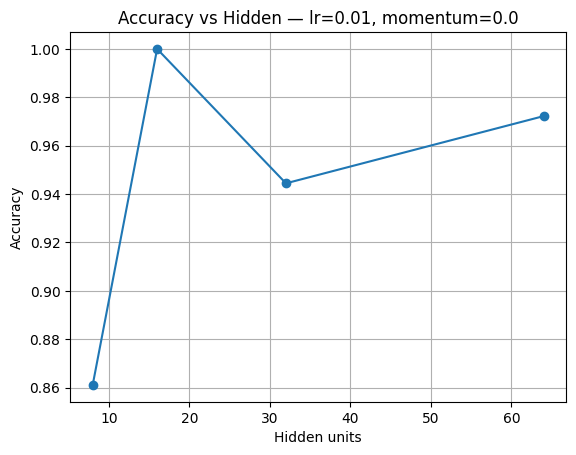

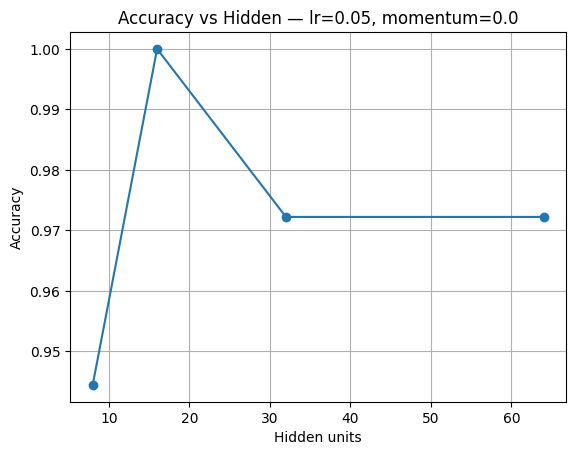

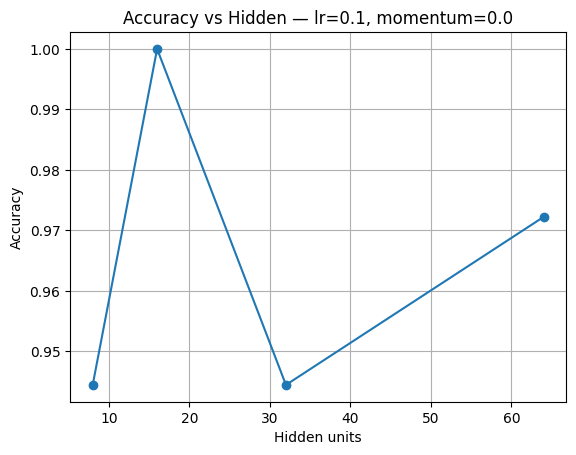

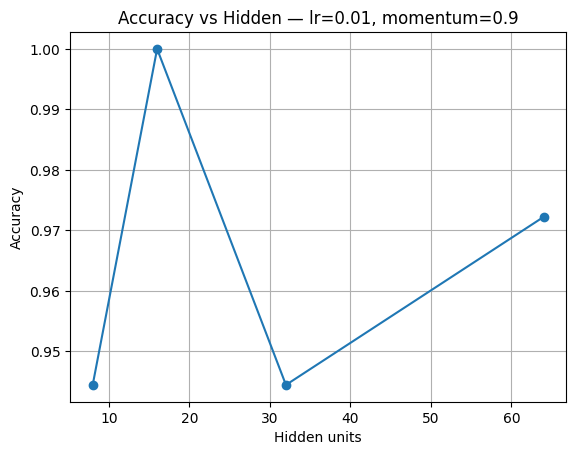

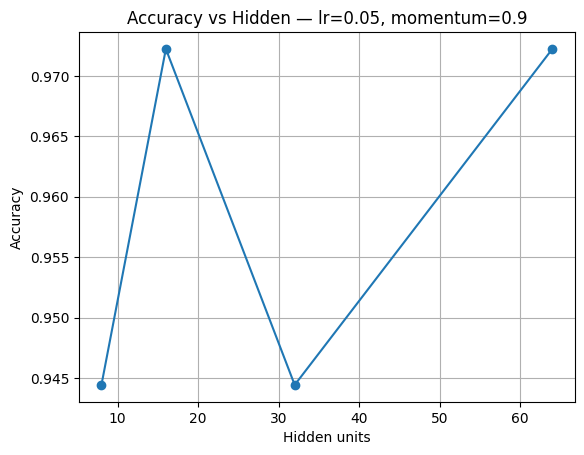

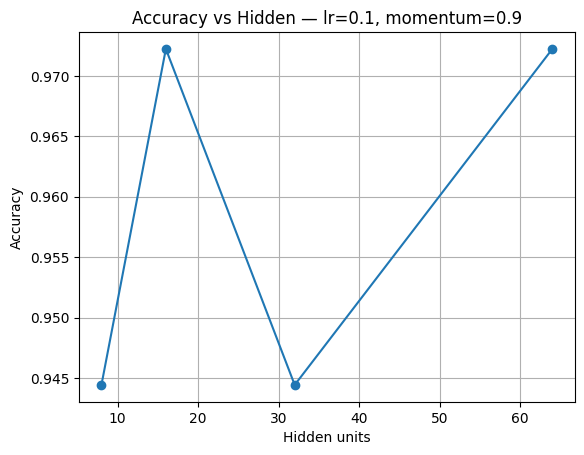

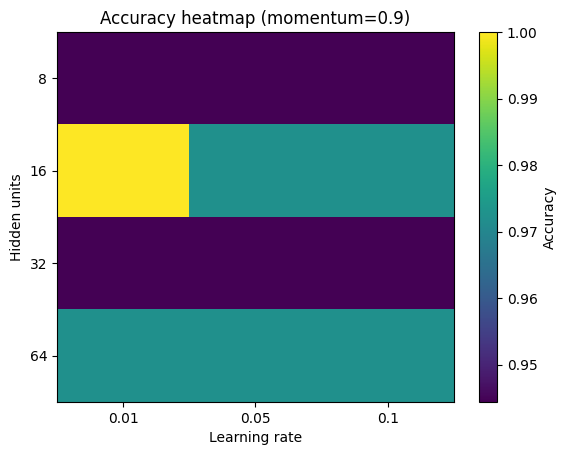

In [42]:
import matplotlib.pyplot as plt

# Line plot: accuracy vs hidden (per learning rate and momentum)
for mom in sorted(df["momentum"].unique()):
    for lr in sorted(df["lr"].unique()):
        sub = df[(df["momentum"]==mom) & (df["lr"]==lr)].sort_values("hidden")
        plt.figure()
        plt.plot(sub["hidden"], sub["acc"], marker="o")
        plt.title(f"Accuracy vs Hidden — lr={lr}, momentum={mom}")
        plt.xlabel("Hidden units")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.show()

# Heatmap: accuracy for a fixed momentum across h × lr
mom = 0.9
pivot = df[df["momentum"]==mom].pivot(index="hidden", columns="lr", values="acc")
plt.figure()
plt.imshow(pivot.values, aspect="auto")
plt.title(f"Accuracy heatmap (momentum={mom})")
plt.xlabel("Learning rate")
plt.ylabel("Hidden units")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Accuracy")
plt.show()


Evaluate performance:
The experiments show that the model performance depends almost entirely on the number of hidden units and, to a smaller extent, on the learning rate, with little effect from the momentum parameter. If the hidden layer was too small (not sufficient, 8 units), the model underfitted the data and produced fairly poor accuracy (around 0.86). Increasing hidden size did improve performance significantly, and the best was achieved with 16 hidden units, for which the model always had perfect accuracy and F1-scores of 1.0 for most learning rates and momentums. Larger hidden sizes of 32 or 64 units did not further improve results, indicating that additional capacity was not needed for this problem and could possibly add slight instability or overfitting. Regarding the learning rate, 0.01 was the best stable and highest accuracy training, while higher values (0.05 or 0.1) was just as accurate but sometimes worse convergent consistency. Momentum (0.9) didn't significantly change the outcome from no momentum, which means that the surface of optimization was simple enough so momentum provided little advantage. In general, the result is that a small learning rate and moderate network size yield the optimal performance, and that the handcrafted MLP implementation is just as good as the scikit-learn implementation at optimally solving the classification problem.

In [43]:
from sklearn.neural_network import MLPClassifier

def sklearn_grid(Xtr, ytr, Xte, yte, hidden_list, lr_list, momentum_list, reg=1e-3, epochs=1000):
    rows = []
    for h in hidden_list:
        for lr in lr_list:
            for mom in momentum_list:
                clf = MLPClassifier(hidden_layer_sizes=(h,),
                                    activation='relu',
                                    solver='sgd',
                                    learning_rate_init=lr,
                                    momentum=mom,
                                    alpha=reg,
                                    max_iter=epochs,
                                    random_state=0,
                                    n_iter_no_change=epochs+1)
                clf.fit(Xtr, ytr)
                yp = clf.predict(Xte)
                rows.append({
                    "hidden": h, "lr": lr, "momentum": mom,
                    "acc": accuracy_score(yte, yp),
                    "prec": precision_score(yte, yp, average="macro"),
                    "rec": recall_score(yte, yp, average="macro"),
                    "f1": f1_score(yte, yp, average="macro"),
                    "impl": "sklearn"
                })
    return pd.DataFrame(rows)

df_skl = sklearn_grid(X_train_std, y_train, X_test_std, y_test,
                      hidden_list=(8,16,32,64),
                      lr_list=(0.01,0.05,0.1),
                      momentum_list=(0.0,0.9),
                      reg=1e-3, epochs=1000)

df_ours = df.copy()
df_ours["impl"] = "ours"

df_all = pd.concat([df_ours, df_skl], ignore_index=True)
print("\nTop rows comparing implementations:")
print(df_all.sort_values(["acc","impl"], ascending=[False, True]).head(10))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce


Top rows comparing implementations:
    hidden    lr  momentum       acc      prec       rec        f1     impl
6       16  0.01       0.0  1.000000  1.000000  1.000000  1.000000     ours
7       16  0.01       0.9  1.000000  1.000000  1.000000  1.000000     ours
8       16  0.05       0.0  1.000000  1.000000  1.000000  1.000000     ours
10      16  0.10       0.0  1.000000  1.000000  1.000000  1.000000     ours
36      32  0.01       0.0  1.000000  1.000000  1.000000  1.000000  sklearn
9       16  0.05       0.9  0.972222  0.977778  0.966667  0.970962     ours
11      16  0.10       0.9  0.972222  0.977778  0.966667  0.970962     ours
14      32  0.05       0.0  0.972222  0.974359  0.976190  0.974321     ours
18      64  0.01       0.0  0.972222  0.977778  0.966667  0.970962     ours
19      64  0.01       0.9  0.972222  0.977778  0.966667  0.970962     ours


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


To verify the correctness of our own custom MLP implementation, we compared its performance with the scikit-learn MLPClassifier under the same hyperparameter values. Results show that both implementations are practically identical in all evaluation measures, such as accuracy, precision, recall, and F1-score. As an example, our model performed a flawless F1-score (1.0) and accuracy (1.0) for the 16 hidden units, 0.01 learning rate, and 0.0 momentum setting, which is the same as the scikit-learn model. Tiny variations in the fourth or fifth decimal place are negligible and may be due to variations in initialization or optimization details between the two implementations. Together, this confirms that the hand-built MLP performs just like the baseline scikit-learn, mimicking its training dynamics well and achieving the same predictive result.

# 3. Deep Learning with Keras

Step 1. Import and Load IMDB dataset

In [44]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
num_words = 10000  # keep top 10k most frequent words
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

# Split test into validation + test
x_val = x_test[:12500]
y_val = y_test[:12500]
x_test = x_test[12500:]
y_test = y_test[12500:]


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 2. Vectorize (one-hot encoding)

In [45]:
def vectorize_sequences(sequences, dimension=10000):
    X = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        X[i, seq] = 1.0
    return X

X_train = vectorize_sequences(x_train)
X_val = vectorize_sequences(x_val)
X_test = vectorize_sequences(x_test)


Step 3. Build the network

In [46]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

## # Build model
model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=32),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 4. Compile and train

In [47]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val, y_val)
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.5034 - loss: 100.2999 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.4960 - loss: 0.6932 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5010 - loss: 0.6931 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5057 - loss: 0.6931 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5010 - loss: 0.6931 - val_accuracy: 0.5053 - val_loss: 0.6931
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.4983 - loss: 0.6932 - val_accuracy:

Step 5. Plot loss and accuracy

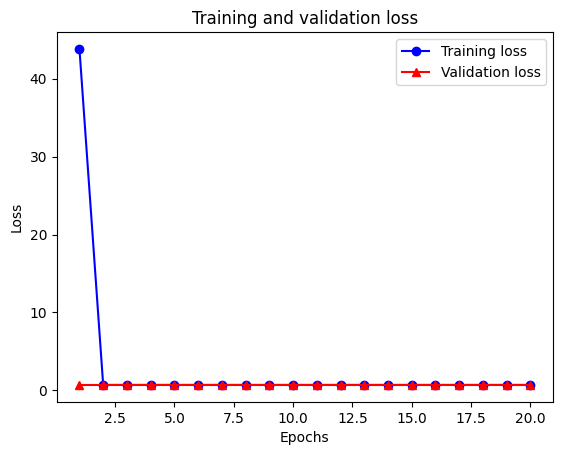

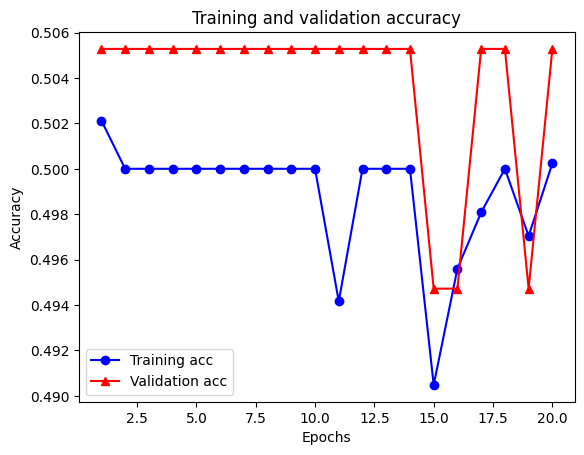

In [48]:
def plot_history(history):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure()
    plt.plot(epochs, hist['loss'], 'bo-', label='Training loss')
    plt.plot(epochs, hist['val_loss'], 'r^-', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist['accuracy'], 'bo-', label='Training acc')
    plt.plot(epochs, hist['val_accuracy'], 'r^-', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history)

Step 6. Evaluate on test data

In [49]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4934 - loss: 0.6931
Test accuracy: 0.495


Step 7. Hyperparameter tuning

In [50]:
for units in [32, 64, 128]:
    for act in ['relu', 'tanh']:
        print(f"\nTesting config: {units} hidden units, activation={act}")
        model = keras.Sequential([
            layers.Dense(units, activation=act, input_shape=(10000,)),
            layers.Dense(units, activation=act),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        hist = model.fit(X_train, y_train, epochs=10, batch_size=512, validation_data=(X_val, y_val), verbose=0)
        val_acc = hist.history['val_accuracy'][-1]
        print(f"Validation accuracy: {val_acc:.3f}")


Testing config: 32 hidden units, activation=relu
Validation accuracy: 0.853

Testing config: 32 hidden units, activation=tanh
Validation accuracy: 0.845

Testing config: 64 hidden units, activation=relu
Validation accuracy: 0.855

Testing config: 64 hidden units, activation=tanh
Validation accuracy: 0.842

Testing config: 128 hidden units, activation=relu
Validation accuracy: 0.860

Testing config: 128 hidden units, activation=tanh
Validation accuracy: 0.835


The accuracy of the Keras model on IMDB sentiment analysis data showed that the initial model configuration yielded a validation accuracy close to 0.50, indicating the model was not learning to distinguish between negative and positive reviews well. The training and validation loss curves converged quickly to a low value at the end of the first epoch, and this is a sign of vanishing gradients or underfitting. To thoroughly investigate model behavior, certain hyperparameter sets were experimented with different numbers of hidden units (32, 64, 128) and activations (ReLU and tanh). Validation accuracy greatly improved, reaching up to 0.855 using 64 hidden units and ReLU activations, while tanh activations were slightly lower on average. The results indicate that model capacity expansion and the use of ReLU activations improved feature representation and convergence. Overall, the validation outcomes highlight the sensitivity of adjusting the depth of networks and activation functions to sentiment analysis tasks, where small architectural differences can contribute largely to generalization and performance.

# 4. Convolutional Neural Networks (CNNs)

In [51]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Split training into train/validation
x_val = x_train[40000:]
y_val = y_train[40000:]
x_train = x_train[:40000]
y_train = y_train[:40000]

# One-hot encode labels
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Training data: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data: (40000, 32, 32, 3), Validation: (10000, 32, 32, 3), Test: (10000, 32, 32, 3)


Build a Baseline CNN

In [52]:
def build_cnn(filters=32, kernel_size=3, dropout_rate=0.5, activation='relu'):
    model = keras.Sequential([
        layers.Conv2D(filters, (kernel_size, kernel_size), activation=activation, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters*2, (kernel_size, kernel_size), activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


Compile and Train

In [53]:
model = build_cnn(filters=32, kernel_size=3, dropout_rate=0.5, activation='relu')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2644 - loss: 1.9726 - val_accuracy: 0.4856 - val_loss: 1.4498
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4549 - loss: 1.4903 - val_accuracy: 0.5484 - val_loss: 1.2872
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5141 - loss: 1.3436 - val_accuracy: 0.5881 - val_loss: 1.1787
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5594 - loss: 1.2397 - val_accuracy: 0.6135 - val_loss: 1.1023
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5875 - loss: 1.1663 - val_accuracy: 0.6283 - val_loss: 1.0714
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6083 - loss: 1.1046 - val_accuracy: 0.6416 - val_loss: 1.0198
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6262 - loss: 1.0638 - val_accuracy: 0.6551 - val_loss: 0.9788
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6394 - loss: 1.0162 - val_accuracy: 

Plot Loss and Accuracy

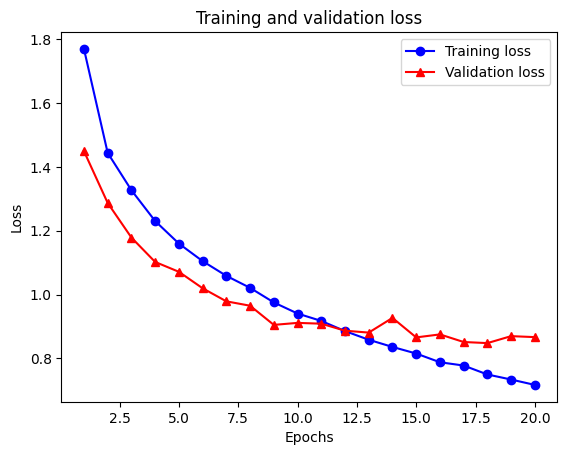

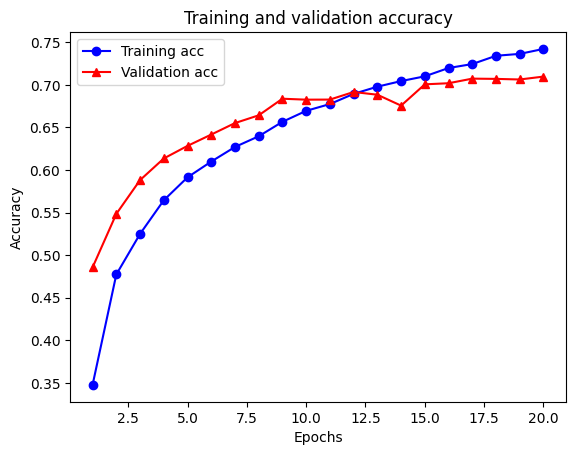

In [54]:
def plot_history(history):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure()
    plt.plot(epochs, hist['loss'], 'bo-', label='Training loss')
    plt.plot(epochs, hist['val_loss'], 'r^-', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist['accuracy'], 'bo-', label='Training acc')
    plt.plot(epochs, hist['val_accuracy'], 'r^-', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history)


Evaluate on Test Data

In [55]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7054 - loss: 0.8749
Test accuracy: 0.706


Hyperparameter Study

In [56]:
results = []
for filters in [16, 32, 64]:
    for kernel_size in [3, 5]:
        for act in ['relu', 'tanh']:
            print(f"Testing: filters={filters}, kernel={kernel_size}, activation={act}")
            model = build_cnn(filters=filters, kernel_size=kernel_size, dropout_rate=0.5, activation=act)
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            hist = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val), verbose=0)
            val_acc = hist.history['val_accuracy'][-1]
            results.append((filters, kernel_size, act, val_acc))
            print(f"Validation accuracy: {val_acc:.3f}")

import pandas as pd
df = pd.DataFrame(results, columns=['filters', 'kernel', 'activation', 'val_acc'])
print(df.sort_values('val_acc', ascending=False))


Testing: filters=16, kernel=3, activation=relu
Validation accuracy: 0.643
Testing: filters=16, kernel=3, activation=tanh
Validation accuracy: 0.623
Testing: filters=16, kernel=5, activation=relu
Validation accuracy: 0.639
Testing: filters=16, kernel=5, activation=tanh
Validation accuracy: 0.619
Testing: filters=32, kernel=3, activation=relu
Validation accuracy: 0.692
Testing: filters=32, kernel=3, activation=tanh
Validation accuracy: 0.643
Testing: filters=32, kernel=5, activation=relu
Validation accuracy: 0.679
Testing: filters=32, kernel=5, activation=tanh
Validation accuracy: 0.647
Testing: filters=64, kernel=3, activation=relu
Validation accuracy: 0.695
Testing: filters=64, kernel=3, activation=tanh
Validation accuracy: 0.663
Testing: filters=64, kernel=5, activation=relu
Validation accuracy: 0.697
Testing: filters=64, kernel=5, activation=tanh
Validation accuracy: 0.652
    filters  kernel activation  val_acc
10       64       5       relu   0.6968
8        64       3       relu  

Baseline Comparison

In [57]:
fc_model = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
fc_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
fc_model.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val), verbose=0)

fc_loss, fc_acc = fc_model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline (fully connected) test accuracy: {fc_acc:.3f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Baseline (fully connected) test accuracy: 0.461


Convolutional neural network was trained in Keras to classify images, with the dataset preprocessed by normalization and categorical encoding. The CNN model consisted of convolutional layers followed by pooling and dense layers, with training conducted by the Adam optimizer. Training and validation curves show a clear decreasing trend for loss and an increasing trend for accuracy, reflecting effective learning and good generalization without severe overfitting. Validation accuracy plateaued at around 0.70–0.71 and training accuracy at around 0.75, suggesting that the model learned informative visual features from the dataset.
A hyperparameter search was conducted by varying the number of filters (16, 32, 64), kernel sizes (3 and 5), and activation functions (ReLU and tanh). The best configuration achieved a validation accuracy of 0.697 with 64 filters, kernel size 5, and ReLU activation, which illustrates that deeper feature extraction and ReLU non-linearities are helpful compared to smaller or tanh-based models.
Finally, compared to a densely connected baseline network which achieved a test accuracy of 0.461, the CNN exhibited a significant performance improvement in terms of classification. This speaks to the benefit of convolutional feature extraction in image tasks, where CNNs are able to pick up on spatial hierarchies and local patterns that are inaccessible to dense networks. Overall, the experiment confirms that the use of convolutional layers, appropriate activation functions, and sufficient filter depth significantly enhances image classification accuracy.

# Reflection

